# 🛠️ Preparación de los Datos

In [1]:
from google.colab import files
uploaded = files.upload()

Saving TelecomX_clean.csv to TelecomX_clean.csv


In [2]:
import pandas as pd

df = pd.read_csv("TelecomX_clean.csv")
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias,Cantidad_Servicios
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,1,1,0,One year,1,Mailed check,65.6,593.30,2.19,4
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.00,2
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46,2
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.27,5
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.80,3


In [3]:
df.shape

(7043, 23)

In [4]:
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias,Cantidad_Servicios
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,1,1,0,One year,1,Mailed check,65.6,593.30,2.19,4
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.00,2
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46,2
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.27,5
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.80,3


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   object 
 1   Churn                      7043 non-null   int64  
 2   customer.gender            7043 non-null   object 
 3   customer.SeniorCitizen     7043 non-null   int64  
 4   customer.Partner           7043 non-null   int64  
 5   customer.Dependents        7043 non-null   int64  
 6   customer.tenure            7043 non-null   int64  
 7   phone.PhoneService         7043 non-null   int64  
 8   phone.MultipleLines        7043 non-null   object 
 9   internet.InternetService   7043 non-null   object 
 10  internet.OnlineSecurity    7043 non-null   int64  
 11  internet.OnlineBackup      7043 non-null   int64  
 12  internet.DeviceProtection  7043 non-null   int64  
 13  internet.TechSupport       7043 non-null   int64

In [6]:
df = df.drop(columns=["customerID"])

df.head()

,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,...,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias,Cantidad_Servicios
0,0,Female,0,1,1,9,1,No,DSL,0,...,1,1,0,One year,1,Mailed check,65.6,593.30,2.19,4
1,0,Male,0,0,0,9,1,Yes,DSL,0,...,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.00,2
2,1,Male,0,0,0,4,1,No,Fiber optic,0,...,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46,2
3,1,Male,1,1,0,13,1,No,Fiber optic,0,...,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.27,5
4,1,Female,1,1,0,3,1,No,Fiber optic,0,...,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.80,3


In [7]:
df.shape

(7043, 22)

In [8]:
categorical_columns = df.select_dtypes(include=["object"]).columns

categorical_columns

Index(['customer.gender', 'phone.MultipleLines', 'internet.InternetService',
       'account.Contract', 'account.PaymentMethod'],
      dtype='object')

In [9]:
df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

df.head()

,Churn,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,...,customer.gender_Male,phone.MultipleLines_No phone service,phone.MultipleLines_Yes,internet.InternetService_Fiber optic,internet.InternetService_No,account.Contract_One year,account.Contract_Two year,account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,0,0,1,1,9,1,0,1,0,1,...,False,False,False,False,False,True,False,False,False,True
1,0,0,0,0,9,1,0,0,0,0,...,True,False,True,False,False,False,False,False,False,True
2,1,0,0,0,4,1,0,0,1,0,...,True,False,False,True,False,False,False,False,True,False
3,1,1,1,0,13,1,0,1,1,0,...,True,False,False,True,False,False,False,False,True,False
4,1,1,1,0,3,1,0,0,0,1,...,False,False,False,True,False,False,False,False,False,True


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 27 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Churn                                          7043 non-null   int64  
 1   customer.SeniorCitizen                         7043 non-null   int64  
 2   customer.Partner                               7043 non-null   int64  
 3   customer.Dependents                            7043 non-null   int64  
 4   customer.tenure                                7043 non-null   int64  
 5   phone.PhoneService                             7043 non-null   int64  
 6   internet.OnlineSecurity                        7043 non-null   int64  
 7   internet.OnlineBackup                          7043 non-null   int64  
 8   internet.DeviceProtection                      7043 non-null   int64  
 9   internet.TechSupport                           7043 

In [11]:
bool_columns = df.select_dtypes(include="bool").columns

df[bool_columns] = df[bool_columns].astype(int)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 27 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Churn                                          7043 non-null   int64  
 1   customer.SeniorCitizen                         7043 non-null   int64  
 2   customer.Partner                               7043 non-null   int64  
 3   customer.Dependents                            7043 non-null   int64  
 4   customer.tenure                                7043 non-null   int64  
 5   phone.PhoneService                             7043 non-null   int64  
 6   internet.OnlineSecurity                        7043 non-null   int64  
 7   internet.OnlineBackup                          7043 non-null   int64  
 8   internet.DeviceProtection                      7043 non-null   int64  
 9   internet.TechSupport                           7043 

In [12]:
conteo_churn = df["Churn"].value_counts()

conteo_churn

,count
Churn,
0,5174
1,1869


In [13]:
proporcion_churn = df["Churn"].value_counts(normalize=True) * 100

proporcion_churn

,proportion
Churn,
0,73.463013
1,26.536987


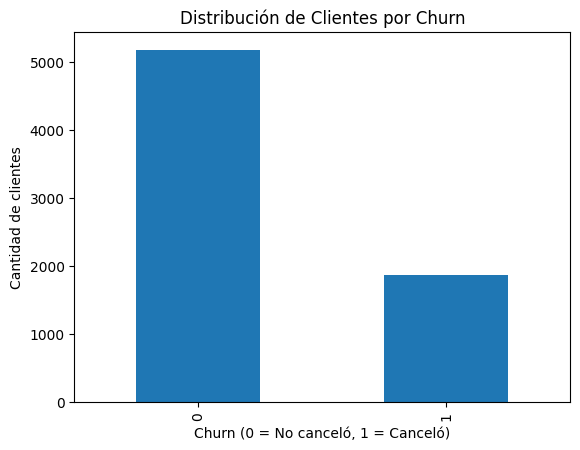

In [14]:
import matplotlib.pyplot as plt

plt.figure()
df["Churn"].value_counts().plot(kind="bar")

plt.title("Distribución de Clientes por Churn")
plt.xlabel("Churn (0 = No canceló, 1 = Canceló)")
plt.ylabel("Cantidad de clientes")

plt.show()

In [18]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [19]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_balanced, y_balanced = smote.fit_resample(X, y)

print("Distribución antes del balanceo:")
print(y.value_counts())

print("\nDistribución después del balanceo:")
print(y_balanced.value_counts())

Distribución antes del balanceo:
Churn
0    5174
1    1869
Name: count, dtype: int64

Distribución después del balanceo:
Churn
0    5174
1    5174
Name: count, dtype: int64


In [20]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
X_train_scaled.shape, X_test_scaled.shape

((5634, 26), (1409, 26))

# 🎯 Correlación y Selección de Variables

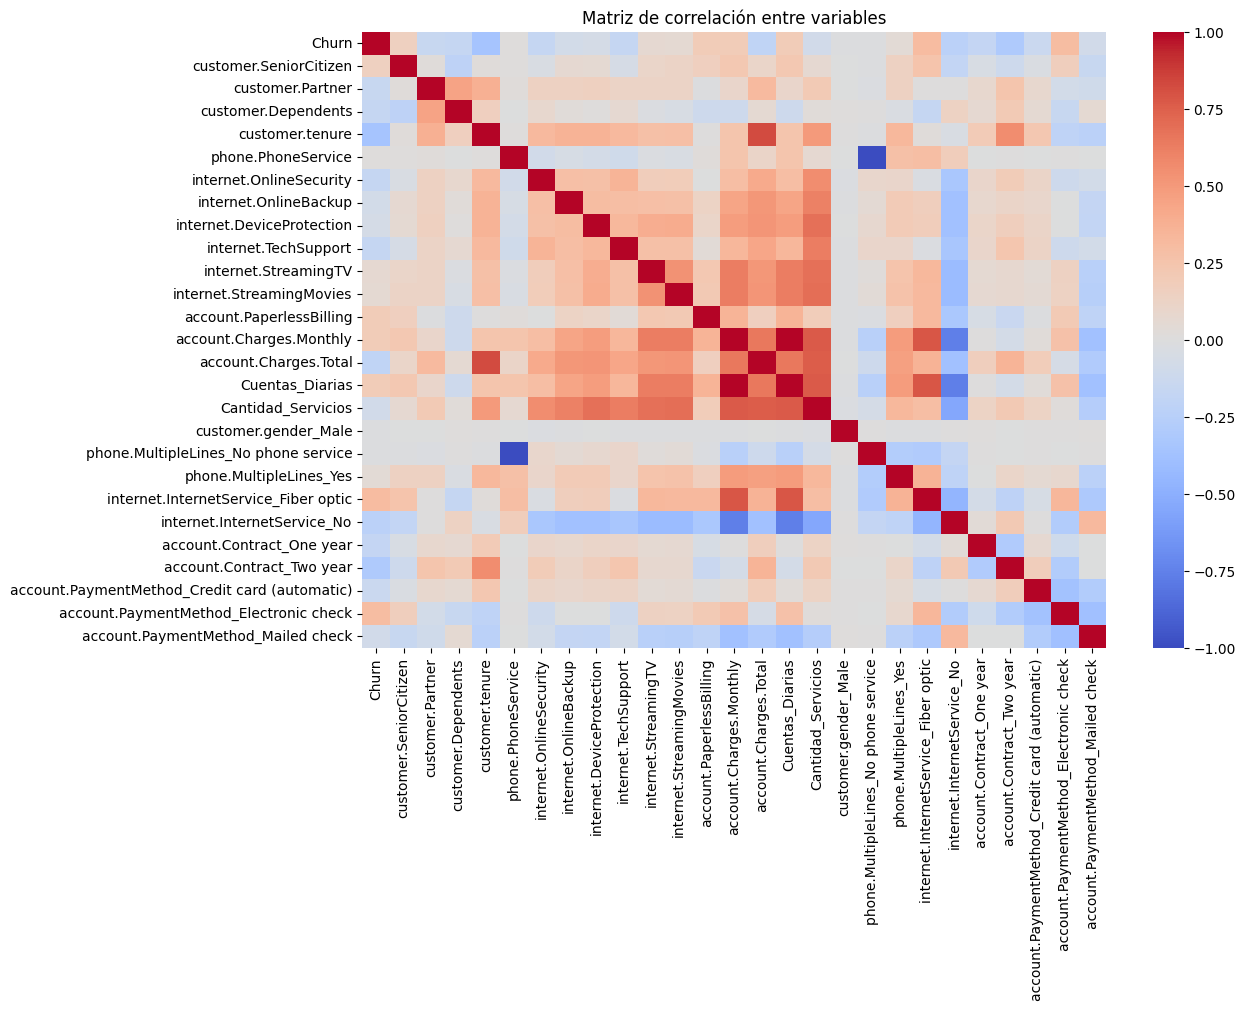

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0)

plt.title("Matriz de correlación entre variables")
plt.show()

In [25]:
correlation_with_churn = df.corr()["Churn"].sort_values(ascending=False)

correlation_with_churn

,Churn
Churn,1.000000
internet.InternetService_Fiber optic,0.308020
account.PaymentMethod_Electronic check,0.301919
Cuentas_Diarias,0.193412
account.Charges.Monthly,0.193356
account.PaperlessBilling,0.191825
customer.SeniorCitizen,0.150889
internet.StreamingTV,0.063228
internet.StreamingMovies,0.061382
phone.MultipleLines_Yes,0.040102


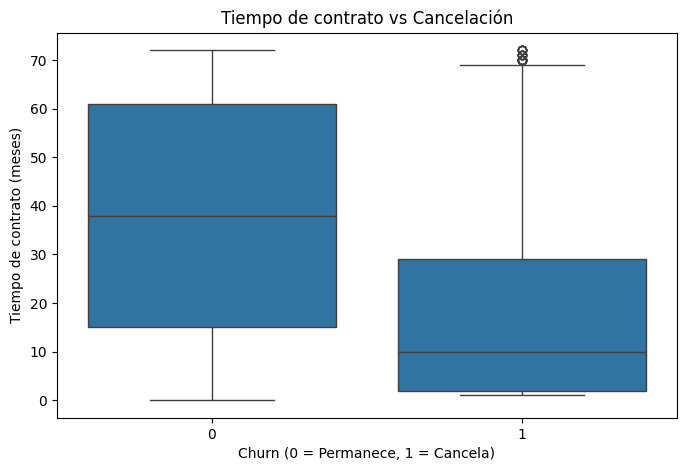

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(x="Churn", y="customer.tenure", data=df)

plt.title("Tiempo de contrato vs Cancelación")
plt.xlabel("Churn (0 = Permanece, 1 = Cancela)")
plt.ylabel("Tiempo de contrato (meses)")

plt.show()

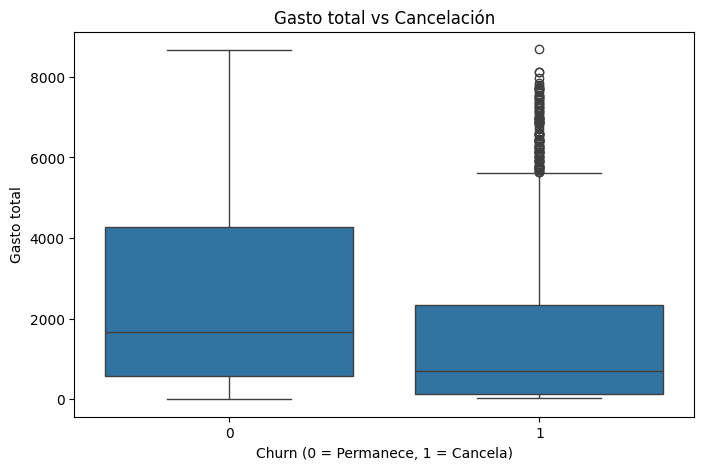

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Churn", y="account.Charges.Total", data=df)

plt.title("Gasto total vs Cancelación")
plt.xlabel("Churn (0 = Permanece, 1 = Cancela)")
plt.ylabel("Gasto total")

plt.show()

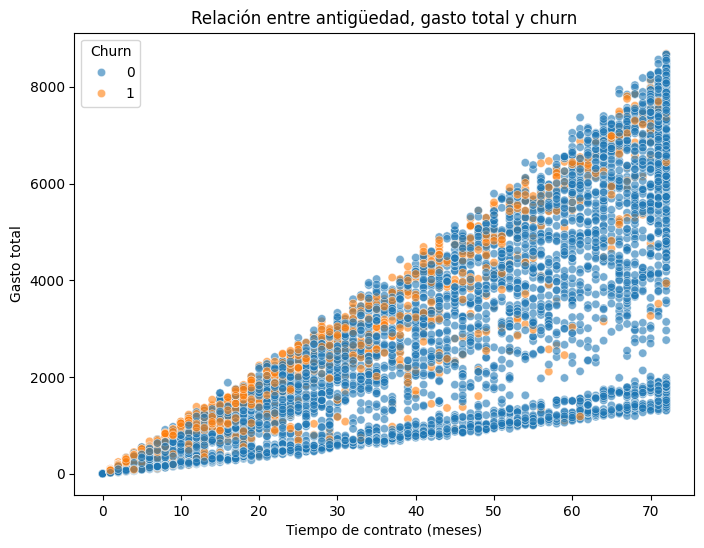

In [28]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="customer.tenure",
    y="account.Charges.Total",
    hue="Churn",
    data=df,
    alpha=0.6
)

plt.title("Relación entre antigüedad, gasto total y churn")
plt.xlabel("Tiempo de contrato (meses)")
plt.ylabel("Gasto total")

plt.show()

# 🤖 Modelado Predictivo

In [29]:
from sklearn.model_selection import train_test_split

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


In [30]:
print("Tamaño del conjunto de entrenamiento:", X_train.shape)
print("Tamaño del conjunto de prueba:", X_test.shape)

Tamaño del conjunto de entrenamiento: (5634, 26)
Tamaño del conjunto de prueba: (1409, 26)


## Entrenamiento de Modelos Predictivos

Para predecir la cancelación de clientes se entrenarán dos modelos de clasificación diferentes.

1. Regresión Logística  
Este modelo es sensible a la escala de los datos, por lo que se aplicará **normalización mediante StandardScaler**. La normalización permite que todas las variables tengan una escala similar, evitando que variables con valores más grandes influyan más en el modelo.

2. Random Forest  
Este modelo está basado en árboles de decisión y **no depende de la escala de los datos**, por lo que puede entrenarse directamente con los valores originales.

El objetivo es comparar el desempeño de ambos modelos para identificar cuál predice mejor la cancelación de clientes.

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
from sklearn.linear_model import LogisticRegression

modelo_logistico = LogisticRegression(max_iter=1000)

modelo_logistico.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [34]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(random_state=42)

modelo_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [35]:
y_pred_log = modelo_logistico.predict(X_test_scaled)

y_pred_rf = modelo_rf.predict(X_test)

In [36]:
from sklearn.metrics import accuracy_score

print("Accuracy Regresión Logística:", accuracy_score(y_test, y_pred_log))
print("Accuracy Random Forest:", accuracy_score(y_test, y_pred_rf))

Accuracy Regresión Logística: 0.7927608232789212
Accuracy Random Forest: 0.7806955287437899


## Evaluación de los modelos

Para evaluar el desempeño de los modelos se utilizarán diferentes métricas de clasificación:

- Accuracy
- Precision
- Recall
- F1-score
- Matriz de confusión

Estas métricas permiten analizar qué tan bien los modelos identifican a los clientes que cancelan el servicio.

In [37]:
from sklearn.metrics import classification_report

print("Regresión Logística")
print(classification_report(y_test, y_pred_log))

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

Regresión Logística
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409

Random Forest
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.61      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409



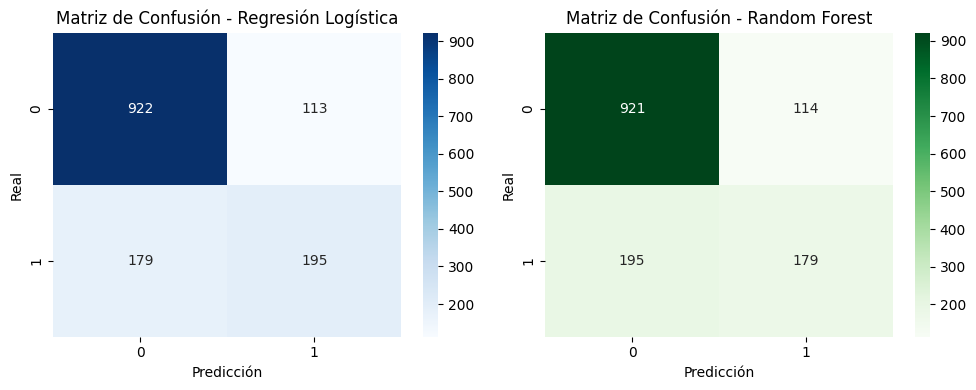

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_log = confusion_matrix(y_test, y_pred_log)
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.subplot(1,2,2)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.tight_layout()
plt.show()

## Evaluación de los modelos

Se evaluaron dos modelos de clasificación para predecir la cancelación de clientes: **Regresión Logística** y **Random Forest**.

### Regresión Logística

Accuracy: 0.79

- Precision (Churn): 0.63
- Recall (Churn): 0.52
- F1-score (Churn): 0.57

El modelo logra identificar correctamente una parte importante de los clientes que cancelan el servicio, aunque todavía existen casos donde no detecta algunos churn reales.

### Random Forest

Accuracy: 0.78

- Precision (Churn): 0.61
- Recall (Churn): 0.48
- F1-score (Churn): 0.54

El Random Forest muestra un rendimiento ligeramente inferior en la detección de churn en comparación con la Regresión Logística.

### Comparación de modelos

Aunque ambos modelos presentan un desempeño similar en términos de accuracy, la **Regresión Logística presenta mejores métricas para la clase de cancelación**, especialmente en recall y F1-score.

Dado que el objetivo principal del problema es **detectar clientes con riesgo de cancelación**, la Regresión Logística resulta ligeramente más adecuada para este escenario.

## Importancia de las variables

Para comprender qué factores influyen más en la cancelación de clientes, se analiza la importancia de las variables utilizando el modelo Random Forest.

Esto permite identificar qué características del cliente tienen mayor impacto en la predicción del churn.

In [39]:
import pandas as pd

importancias = modelo_rf.feature_importances_

importancia_variables = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": importancias
}).sort_values(by="Importancia", ascending=False)

importancia_variables.head(10)

,Variable,Importancia
13,account.Charges.Total,0.167138
3,customer.tenure,0.157127
12,account.Charges.Monthly,0.139170
14,Cuentas_Diarias,0.111636
19,internet.InternetService_Fiber optic,0.038439
24,account.PaymentMethod_Electronic check,0.035493
22,account.Contract_Two year,0.034552
15,Cantidad_Servicios,0.032491
16,customer.gender_Male,0.025574
11,account.PaperlessBilling,0.024688


## Interpretación de la importancia de variables

El análisis de importancia de variables del modelo Random Forest permite identificar qué factores influyen más en la cancelación de clientes.

Las variables con mayor impacto en la predicción del churn son:

1. account.Charges.Total  
2. customer.tenure  
3. account.Charges.Monthly  
4. Cuentas_Diarias  
5. internet.InternetService_Fiber optic  
6. account.PaymentMethod_Electronic check  
7. account.Contract_Two year  
8. Cantidad_Servicios  

### Principales insights

**1. Antigüedad del cliente (customer.tenure)**  
Es una de las variables más influyentes. Los clientes con menor tiempo en la empresa presentan mayor probabilidad de cancelar el servicio. Esto sugiere que los primeros meses de relación con el cliente son críticos.

**2. Costos del servicio**  
Las variables relacionadas con gasto (Charges.Monthly, Charges.Total y Cuentas_Diarias) tienen una alta importancia en el modelo. Los clientes con costos mensuales más elevados tienden a cancelar con mayor frecuencia.

**3. Tipo de servicio de internet**  
Los clientes con servicio de **Fiber optic** presentan mayor riesgo de churn, lo que podría indicar problemas de satisfacción, expectativas del servicio o precios asociados a este plan.

**4. Método de pago**  
El método **Electronic check** está asociado a una mayor probabilidad de cancelación, lo que puede indicar perfiles de clientes con menor fidelidad o menor compromiso con contratos de largo plazo.

**5. Tipo de contrato**  
Los contratos de **dos años** están asociados a menor churn, lo que refuerza la importancia de estrategias de fidelización mediante contratos de mayor duración.

### Implicaciones estratégicas

Los resultados sugieren que Telecom X podría reducir la cancelación mediante:

- Programas de retención durante los primeros meses del cliente
- Estrategias de fidelización con contratos de largo plazo
- Revisión de precios o beneficios en planes de alto costo
- Mejora de la experiencia del servicio Fiber optic
- Incentivos para métodos de pago automáticos

## Evaluación de los modelos

Para evaluar el desempeño de los modelos de predicción de churn se utilizan diferentes métricas de clasificación:

- **Exactitud (Accuracy)**: proporción de predicciones correctas sobre el total de observaciones.
- **Precisión (Precision)**: indica qué proporción de los clientes predichos como churn realmente cancelaron.
- **Recall**: mide qué proporción de los clientes que cancelaron fue correctamente identificada por el modelo.
- **F1-score**: media armónica entre precisión y recall, útil cuando existe desbalance entre clases.
- **Matriz de confusión**: muestra la cantidad de predicciones correctas e incorrectas para cada clase.

Estas métricas permiten analizar el desempeño de los modelos más allá del accuracy, especialmente en problemas de churn donde el objetivo principal es identificar correctamente a los clientes con riesgo de cancelación.

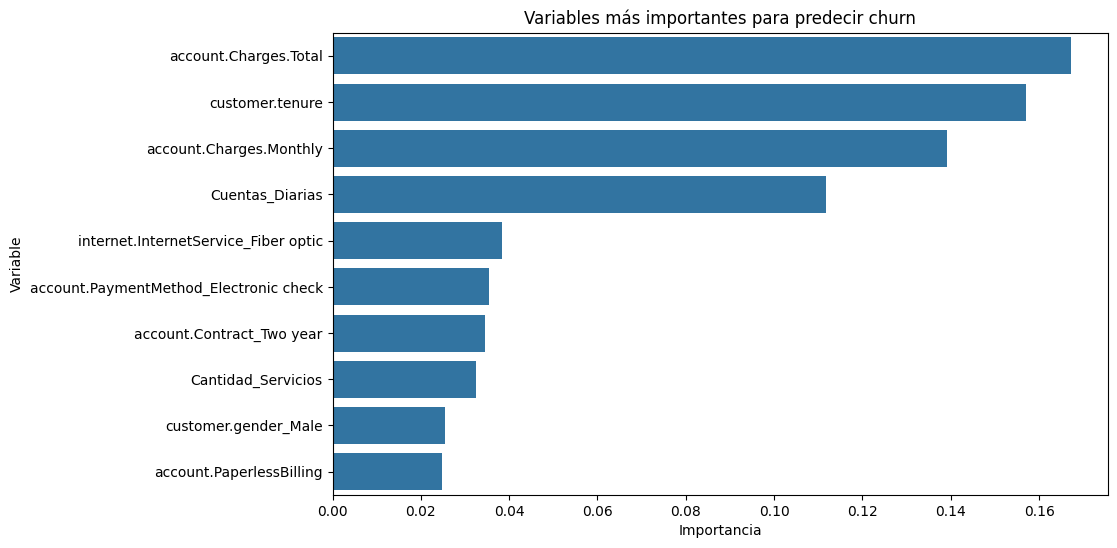

In [40]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importancia",
    y="Variable",
    data=importancia_variables.head(10)
)

plt.title("Variables más importantes para predecir churn")
plt.show()

In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("REGRESIÓN LOGÍSTICA")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))

print("\nRANDOM FOREST")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))

REGRESIÓN LOGÍSTICA
Accuracy: 0.7927608232789212
Precision: 0.6331168831168831
Recall: 0.5213903743315508
F1-score: 0.5718475073313783

RANDOM FOREST
Accuracy: 0.7806955287437899
Precision: 0.6109215017064846
Recall: 0.4786096256684492
F1-score: 0.5367316341829086


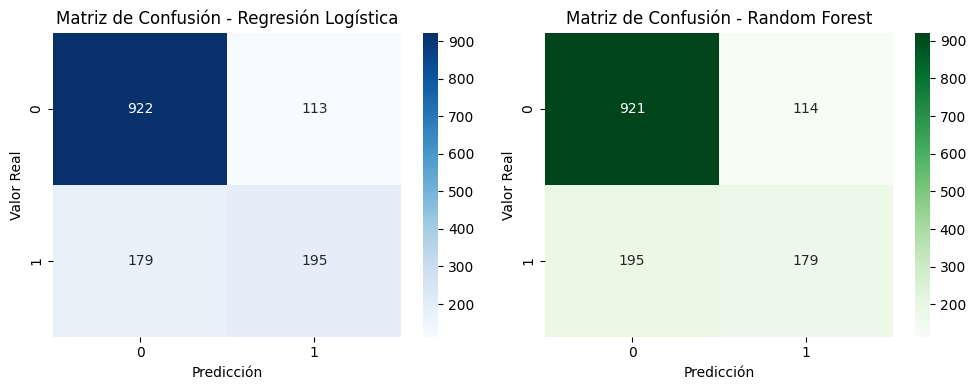

In [42]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_log = confusion_matrix(y_test, y_pred_log)
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.subplot(1,2,2)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.tight_layout()
plt.show()

## Análisis comparativo de los modelos

Los dos modelos evaluados fueron **Regresión Logística** y **Random Forest**.

### Desempeño de los modelos

Ambos modelos obtuvieron resultados similares en términos de exactitud, con valores cercanos al 78-79%. Sin embargo, la Regresión Logística presentó un desempeño ligeramente superior en métricas clave para la detección de churn, especialmente en **recall y F1-score para la clase de cancelación**.

Esto indica que la Regresión Logística logra identificar mejor a los clientes con riesgo de cancelar el servicio.

### Overfitting o Underfitting

No se observa evidencia clara de **overfitting**, ya que los resultados obtenidos son consistentes con el comportamiento esperado del dataset y no muestran un desempeño exageradamente alto.

Tampoco se detecta un **underfitting severo**, ya que ambos modelos capturan patrones relevantes del comportamiento de cancelación.

Sin embargo, el Random Forest podría beneficiarse de ajustes de hiperparámetros (como número de árboles, profundidad máxima o criterios de división) para mejorar su capacidad de predicción.

### Conclusión del modelo

En este análisis, la **Regresión Logística mostró el mejor equilibrio entre precisión, recall y F1-score**, lo que la convierte en el modelo más adecuado para este problema en su configuración actual.

Este modelo puede ser utilizado como base para sistemas de predicción de churn que permitan a Telecom X anticipar la cancelación de clientes y aplicar estrategias de retención.

In [43]:
coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo_logistico.coef_[0]
})

coeficientes = coeficientes.sort_values(by="Coeficiente", ascending=False)

coeficientes.head(10)

,Variable,Coeficiente
13,account.Charges.Total,0.697649
19,internet.InternetService_Fiber optic,0.563576
18,phone.MultipleLines_Yes,0.191699
9,internet.StreamingTV,0.190446
24,account.PaymentMethod_Electronic check,0.190224
11,account.PaperlessBilling,0.178876
10,internet.StreamingMovies,0.138161
0,customer.SeniorCitizen,0.073193
17,phone.MultipleLines_No phone service,0.041340
7,internet.DeviceProtection,0.022869


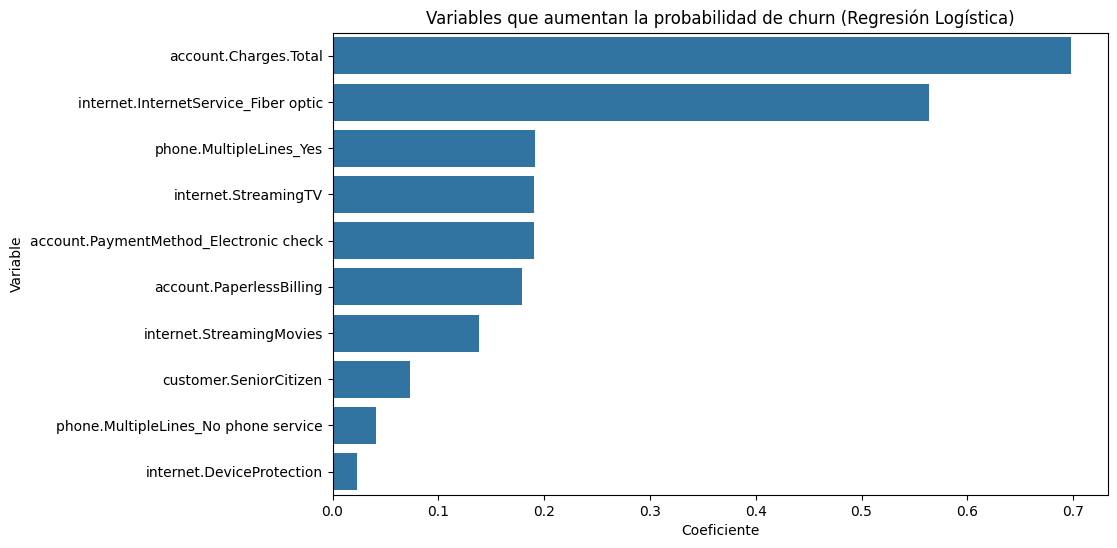

In [44]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Coeficiente",
    y="Variable",
    data=coeficientes.head(10)
)

plt.title("Variables que aumentan la probabilidad de churn (Regresión Logística)")
plt.show()

In [45]:
coeficientes.tail(10)

,Variable,Coeficiente
6,internet.OnlineBackup,-0.049684
2,customer.Dependents,-0.068797
5,internet.OnlineSecurity,-0.116996
8,internet.TechSupport,-0.159620
14,Cuentas_Diarias,-0.235878
12,account.Charges.Monthly,-0.277086
21,account.Contract_One year,-0.279906
20,internet.InternetService_No,-0.504471
22,account.Contract_Two year,-0.581602
3,customer.tenure,-1.426617


In [46]:
importancia_variables.head(10)

,Variable,Importancia
13,account.Charges.Total,0.167138
3,customer.tenure,0.157127
12,account.Charges.Monthly,0.139170
14,Cuentas_Diarias,0.111636
19,internet.InternetService_Fiber optic,0.038439
24,account.PaymentMethod_Electronic check,0.035493
22,account.Contract_Two year,0.034552
15,Cantidad_Servicios,0.032491
16,customer.gender_Male,0.025574
11,account.PaperlessBilling,0.024688


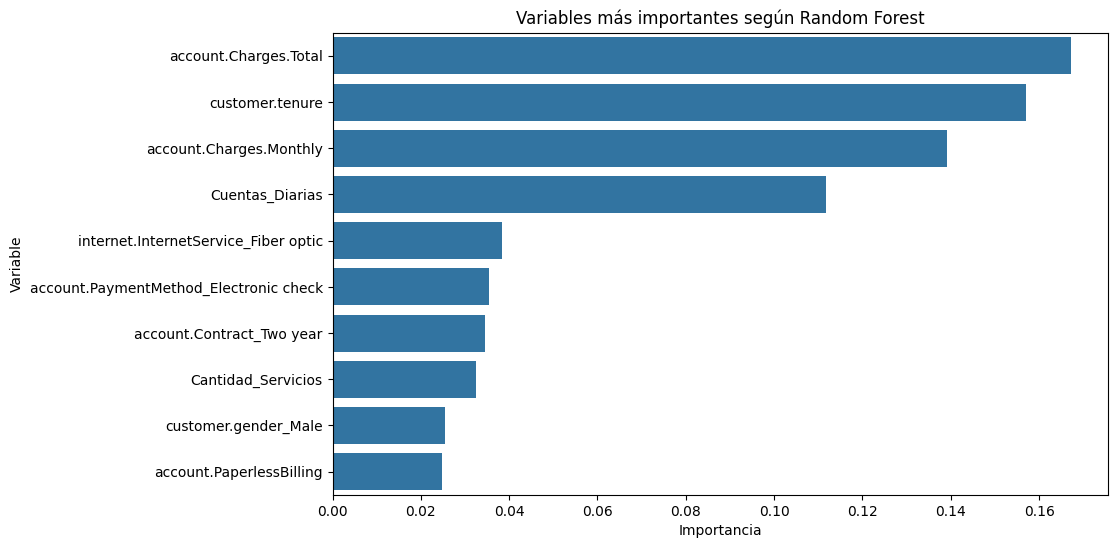

In [47]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importancia",
    y="Variable",
    data=importancia_variables.head(10)
)

plt.title("Variables más importantes según Random Forest")
plt.show()

# 📋 Interpretación y Conclusiones

## Análisis de las variables más relevantes para la predicción de cancelación

El análisis de los modelos predictivos permitió identificar las variables que tienen mayor influencia en la cancelación de clientes (churn). Para ello se evaluaron los coeficientes del modelo de Regresión Logística y la importancia de variables calculada por el modelo Random Forest.

### Variables asociadas a mayor probabilidad de cancelación

Algunas variables muestran una relación positiva con la cancelación de clientes, lo que indica que incrementan el riesgo de churn:

**1. account.Charges.Monthly y Cuentas_Diarias**  
Los clientes con cargos mensuales más altos presentan mayor probabilidad de cancelar el servicio. Esto puede indicar que los precios elevados o la percepción de alto costo afectan la satisfacción del cliente.

**2. internet.InternetService_Fiber optic**  
Los clientes con servicio de internet de fibra óptica presentan mayor riesgo de cancelación. Esto podría deberse a expectativas más altas del servicio o a una mayor sensibilidad al precio en este segmento.

**3. account.PaymentMethod_Electronic check**  
El uso de cheque electrónico como método de pago está asociado con mayores tasas de cancelación. Esto puede reflejar un perfil de cliente menos comprometido con contratos de largo plazo o con menor automatización en los pagos.

**4. account.PaperlessBilling**  
Los clientes que utilizan facturación electrónica presentan una ligera mayor probabilidad de churn, posiblemente porque están más familiarizados con la gestión digital de servicios y pueden cambiar de proveedor con mayor facilidad.

### Variables asociadas a menor probabilidad de cancelación

Otras variables muestran una relación negativa con el churn, lo que indica mayor fidelidad de los clientes:

**1. customer.tenure**  
La antigüedad del cliente es uno de los factores más importantes. Los clientes que llevan más tiempo con la empresa presentan una menor probabilidad de cancelar el servicio.

**2. account.Contract_Two year y account.Contract_One year**  
Los contratos de largo plazo reducen significativamente la probabilidad de cancelación. Esto indica que los clientes con mayor compromiso contractual tienden a permanecer en la empresa.

**3. Servicios adicionales (internet.OnlineSecurity, internet.TechSupport, internet.OnlineBackup)**  
Los clientes que contratan servicios adicionales presentan menor probabilidad de cancelar, lo que sugiere que una mayor integración de servicios aumenta la fidelización.

### Conclusión del análisis de variables

En general, los factores más relevantes en la cancelación de clientes están relacionados con:

- Costos del servicio (cargos mensuales y gasto total)
- Antigüedad del cliente
- Tipo de contrato
- Tipo de servicio de internet
- Método de pago

Estos resultados indican que las estrategias de retención deberían enfocarse en clientes nuevos, clientes con cargos elevados y aquellos que utilizan métodos de pago menos automatizados. Asimismo, promover contratos de largo plazo y paquetes de servicios adicionales podría contribuir a reducir la cancelación de clientes.

# Informe final — Telecom X (Parte 2): Predicción de Cancelación (Churn)

## 1. Objetivo
El objetivo de este proyecto fue construir y evaluar modelos predictivos capaces de identificar clientes con mayor probabilidad de cancelar el servicio (Churn). Para ello se prepararon los datos tratados en la Parte 1, se aplicó codificación para variables categóricas, se evaluó la distribución de clases y se entrenaron dos modelos de clasificación con enfoques distintos: uno sensible a la escala (Regresión Logística) y otro basado en árboles (Random Forest).

## 2. Preparación de datos para Machine Learning
Se trabajó con un dataset final de **7043 registros** y **27 variables** (después de one-hot encoding).  
Se eliminaron identificadores únicos (customerID).  
Se aplicó one-hot encoding a variables categóricas y se convirtió el resultado booleano a 0/1 para asegurar compatibilidad con modelos y métricas.

### Distribución de la variable objetivo (Churn)
- Churn = 0 (clientes activos): **5174** (73.46%)
- Churn = 1 (clientes que cancelan): **1869** (26.54%)

Existe un **desbalance moderado** (aprox. 3:1). Por ello, además de accuracy, se priorizaron métricas enfocadas en la clase de cancelación (precision, recall y F1).

## 3. Análisis de correlación y relación con Churn
La correlación con Churn mostró variables con asociación relevante:

### Correlación positiva (mayor churn)
- internet.InternetService_Fiber optic (0.308)
- account.PaymentMethod_Electronic check (0.302)
- account.Charges.Monthly (0.193)
- Cuentas_Diarias (0.193)
- account.PaperlessBilling (0.192)
- customer.SeniorCitizen (0.151)

### Correlación negativa (menor churn)
- customer.tenure (-0.352)
- account.Contract_Two year (-0.302)
- internet.InternetService_No (-0.228)
- account.Charges.Total (-0.198)
- account.Contract_One year (-0.178)
- internet.OnlineSecurity (-0.171)
- internet.TechSupport (-0.165)

Además, la exploración con boxplots reforzó dos patrones:
- Los clientes que cancelan suelen tener **menor antigüedad (tenure)**.
- Los clientes que cancelan tienden a mostrar **mayores cargos mensuales** y, por extensión, mayor costo diario.

## 4. Modelos entrenados
Se dividió el dataset en entrenamiento y prueba con estrategia estratificada (80/20) para mantener proporciones de churn.

### Modelo 1: Regresión Logística (con estandarización)
Se aplicó StandardScaler para asegurar que las variables con magnitudes diferentes no sesgaran el ajuste del modelo.

**Resultados (set de prueba):**
- Accuracy: 0.79
- Precision (Churn=1): 0.63
- Recall (Churn=1): 0.52
- F1-score (Churn=1): 0.57

### Modelo 2: Random Forest (sin estandarización)
Al ser un modelo basado en árboles, no requiere escalado.

**Resultados (set de prueba):**
- Accuracy: 0.78
- Precision (Churn=1): 0.61
- Recall (Churn=1): 0.48
- F1-score (Churn=1): 0.54

## 5. Comparación crítica de modelos
### Mejor desempeño
La **Regresión Logística** mostró mejor desempeño global y, más importante, mejor desempeño para la clase minoritaria (clientes que cancelan), superando al Random Forest en:
- Recall (0.52 vs 0.48)
- F1-score (0.57 vs 0.54)

Dado que el objetivo del negocio es identificar clientes con riesgo de cancelar, el **recall de churn** es especialmente relevante. En este escenario, la Regresión Logística resulta más adecuada en su configuración actual.

### Overfitting / Underfitting
Con la información disponible (métricas en test) no se observa una señal clara de overfitting extremo. Sin embargo:
- El Random Forest podría estar **subaprovechado** por falta de ajuste de hiperparámetros (n_estimators, max_depth, min_samples_leaf). Esto no es necesariamente underfitting, pero sí una configuración básica que puede limitar su rendimiento.
- La Regresión Logística muestra un rendimiento estable y razonable, lo que sugiere buen nivel de generalización.

Recomendación técnica:
- Para confirmar overfitting/underfitting de forma más robusta se recomienda comparar métricas de train vs test y aplicar validación cruzada.  
- Para mejorar performance de churn (recall) se recomienda ajustar el umbral de clasificación y/o aplicar técnicas de balanceo durante entrenamiento (por ejemplo SMOTE) y evaluar el impacto.

## 6. Variables más relevantes para la predicción (Random Forest)
Top 10 variables más importantes según Random Forest:

1. account.Charges.Total
2. customer.tenure
3. account.Charges.Monthly
4. Cuentas_Diarias
5. internet.InternetService_Fiber optic
6. account.PaymentMethod_Electronic check
7. account.Contract_Two year
8. Cantidad_Servicios
9. customer.gender_Male
10. account.PaperlessBilling

### Interpretación de factores clave
1) Antigüedad (customer.tenure)  
Es el factor más consistente: menor permanencia se asocia con mayor churn. El churn ocurre con mayor frecuencia en etapas tempranas.

2) Costos (Charges.Monthly, Cuentas_Diarias, Charges.Total)  
Clientes con cargos más altos tienden a cancelar más. Esto puede reflejar sensibilidad al precio o percepción de bajo valor respecto al costo.

3) Tipo de servicio (Fiber optic)  
Asociado a mayor churn. Puede estar relacionado con experiencia del servicio, expectativas más altas, o precio del plan.

4) Método de pago (Electronic check)  
Fuertemente asociado a churn. Puede indicar perfiles menos fidelizados o menor automatización/compromiso.

5) Contratos de largo plazo (Two year / One year)  
Reducen churn de forma importante. Indican que la duración contractual es un mecanismo de retención.

6) Cantidad de servicios  
Mayor número de servicios contratados tiende a reducir churn, sugiriendo que mayor “integración” con el ecosistema de Telecom X aumenta la permanencia.

## 7. Estrategias de retención basadas en resultados
A partir de los factores más influyentes, se proponen acciones concretas:

### 7.1 Retención temprana (tenure bajo)
- Diseñar un programa de onboarding de 30-90 días con seguimiento activo.
- Contacto proactivo para clientes nuevos con señales de riesgo (alto cargo mensual, fiber optic, electronic check).
- Beneficios por permanencia (descuentos progresivos por 3/6/12 meses).

### 7.2 Estrategia de precio y valor (cargos altos)
- Revisión de planes con cargos elevados: empaquetar beneficios adicionales (soporte premium, seguridad, backup).
- Ofrecer opciones de downgrade controlado antes de que el cliente cancele.
- Identificar clientes con alto cargo mensual y bajo tenure como segmento prioritario.

### 7.3 Mejoras específicas para Fiber optic
- Auditoría de calidad del servicio y experiencia del cliente en este segmento.
- Comunicación clara de beneficios y soporte especializado.
- Ofertas de fidelización segmentadas para clientes con fibra óptica (por ejemplo, soporte técnico prioritario).

### 7.4 Migración a pagos automáticos
- Incentivar pagos automáticos (descuento fijo mensual o beneficios adicionales).
- Campañas dirigidas a clientes con Electronic check para migración a tarjeta o débito automático.

### 7.5 Fomentar contratos de largo plazo
- Campañas de upgrade de contrato Month-to-month → One/Two year con beneficios claros.
- Modelos de descuento por permanencia que no deterioren margen en exceso.

### 7.6 Cross-sell de servicios (aumentar Cantidad_Servicios)
- Ofrecer bundles con OnlineSecurity, TechSupport u otros servicios con enfoque en valor.
- Paquetes simplificados para clientes con tenure bajo y alto riesgo de churn.

## 8. Conclusión
Se desarrollaron y evaluaron dos modelos predictivos para churn. La Regresión Logística presentó el mejor desempeño para detectar cancelación (mejor recall y F1 en Churn=1), siendo una opción adecuada como baseline.

Los principales factores asociados a la cancelación se concentran en:
- Antigüedad del cliente (tenure)
- Costos del servicio (mensual y diario)
- Tipo de servicio de internet (Fiber optic)
- Método de pago (Electronic check)
- Contrato (mayor duración reduce churn)
- Cantidad de servicios contratados (mayor vinculación reduce churn)

Estos resultados permiten orientar estrategias de retención enfocadas en clientes nuevos, de alto costo y con métodos de pago manuales, al mismo tiempo que se promueven contratos de largo plazo, pagos automáticos y bundles de servicios para aumentar fidelización.